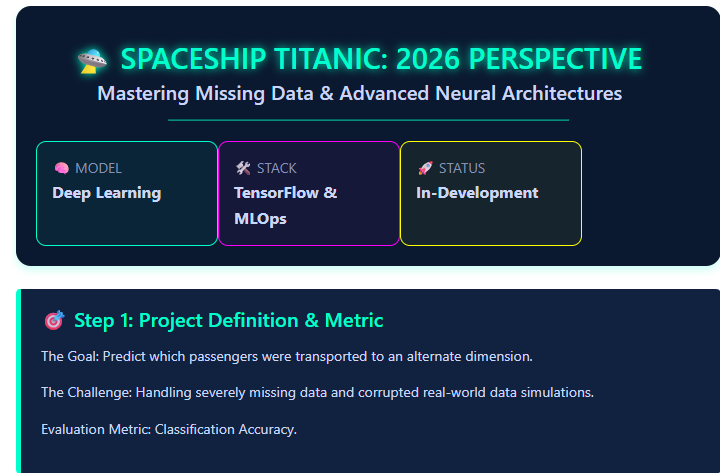



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

In [2]:
# --- NEON THEME SETTINGS ---
sns.set_theme(style="darkgrid", 
              rc={"axes.facecolor": "#121212", "figure.facecolor": "#121212", 
                  "axes.edgecolor":"#00ffcc", "text.color":"#00ffcc", 
                  "xtick.color":"#00ffcc", "ytick.color":"#00ffcc"})
sns.set_palette(sns.color_palette(["#00ffcc", "#ff00ff", "#ffff00"]))

In [3]:
# --- 1. DATA LOADING (Spaceship Titanic) ---
# Import data using pandas
train_df = pd.read_csv('/kaggle/input/competitions/spaceship-titanic/train.csv')
test_df = pd.read_csv('/kaggle/input/competitions/spaceship-titanic/test.csv')

In [4]:
print("="*50)
print(f"🚀 TRAINING DATA SHAPE: {train_df.shape}")
print(f"🛸 TEST DATA SHAPE: {test_df.shape}")
print("="*50 + "\n")

🚀 TRAINING DATA SHAPE: (8693, 14)
🛸 TEST DATA SHAPE: (4277, 13)



In [5]:
# --- 2. MISSING DATA DETECTION & VISUALIZATION ---
# Observe general missing values using df.isnull().sum()
missing_data = train_df.isnull().sum().sort_values(ascending=False)
missing_data = missing_data[missing_data > 0].reset_index()
missing_data.columns = ['Feature', 'Missing Count']

# Plotly Horizontal Bar Chart for Missing Data
fig = px.bar(missing_data, x='Missing Count', y='Feature', orientation='h',
             title='🚨 Spaceship Titanic: The Missing Data Anomaly',
             text='Missing Count', color='Missing Count',
             color_continuous_scale=['#ff00ff', '#00ffcc', '#ffff00']) 

fig.update_layout(plot_bgcolor='#121212', paper_bgcolor='#121212', font_color='#00ffcc',
                  title_font_size=20, xaxis=dict(showgrid=True, gridcolor='#333333'), yaxis=dict(showgrid=False))
fig.update_traces(textposition='outside', marker_line_color='#00ffcc', marker_line_width=1.5)
fig.show()

In [6]:
# Display the first 5 rows
display(train_df.head())

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [7]:
# --- 3. ADVANCED FEATURE ENGINEERING & IMPUTATION ---

def preprocess_data(df):
    # Make a copy to avoid changing the original data immediately
    df_clean = df.copy()
    
    # 1. Feature Engineering: Extract Deck and Side from 'Cabin'
    # Fill missing cabins with 'U/0/U' (Unknown) to prevent errors during split
    df_clean['Cabin'] = df_clean['Cabin'].fillna('U/0/U')
    df_clean['Deck'] = df_clean['Cabin'].apply(lambda x: x.split('/')[0])
    df_clean['Side'] = df_clean['Cabin'].apply(lambda x: x.split('/')[2])
    
    # 2. Imputing Continuous (Numeric) Variables
    # Using median is more robust against outliers than mean
    num_cols = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
    for col in num_cols:
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())
        
    # 3. Imputing Categorical Variables
    # Filling with the most frequent value (mode)
    cat_cols = ['HomePlanet', 'CryoSleep', 'Destination', 'VIP']
    for col in cat_cols:
        df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])
        
    # 4. Creating a New Feature: Total Spending
    df_clean['TotalSpend'] = df_clean['RoomService'] + df_clean['FoodCourt'] + df_clean['ShoppingMall'] + df_clean['Spa'] + df_clean['VRDeck']
    
    # Drop columns that are no longer needed for the Neural Network
    # We keep PassengerId in a safe place for the final Kaggle submission later
    df_clean = df_clean.drop(['Cabin', 'Name'], axis=1)
    
    return df_clean

# Apply the pipeline to both Training and Test data
print("⚙️ Initiating Data Imputation and Feature Engineering Pipeline...")
train_clean = preprocess_data(train_df)
test_clean = preprocess_data(test_df)

# Check if any missing values are left
missing_left = train_clean.isnull().sum().sum()
print(f"✅ Pipeline Execution Complete. Remaining Missing Values: {missing_left}")
print("="*50)

# Display the newly engineered dataset
display(train_clean.head())

⚙️ Initiating Data Imputation and Feature Engineering Pipeline...
✅ Pipeline Execution Complete. Remaining Missing Values: 0


,PassengerId,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,Deck,Side,TotalSpend
0,0001_01,Europa,False,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,False,B,P,0.0
1,0002_01,Earth,False,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,True,F,S,736.0
2,0003_01,Europa,False,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,False,A,S,10383.0
3,0003_02,Europa,False,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,False,A,S,5176.0
4,0004_01,Earth,False,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,True,F,S,1091.0


In [8]:
# --- 4. CATEGORICAL ENCODING & DATA SPLITTING (X, y) ---

print("⚙️ Executing One-Hot Encoding for Neural Network compatibility...")

# 1. Select the categorical columns we generated and kept
cat_cols_to_encode = ['HomePlanet', 'CryoSleep', 'Destination', 'VIP', 'Deck', 'Side']

# 2. Apply One-Hot Encoding (pd.get_dummies)
train_encoded = pd.get_dummies(train_clean, columns=cat_cols_to_encode, drop_first=True)
test_encoded = pd.get_dummies(test_clean, columns=cat_cols_to_encode, drop_first=True)

# 3. Define Features (X) and Target (y)
y = train_encoded['Transported'].astype(int) # Convert True/False target to 1/0
X = train_encoded.drop(['PassengerId', 'Transported'], axis=1)

# Prepare the Test set (Drop PassengerId as it is not a predictive feature)
X_test = test_encoded.drop(['PassengerId'], axis=1)

# 4. MLOps Best Practice: Align train and test columns
# This prevents errors if a category exists in train data but is missing in test data
X, X_test = X.align(X_test, join='left', axis=1, fill_value=0)

# 5. Convert all data to float for the TensorFlow/Keras Neural Engine
X = X.astype(float)
X_test = X_test.astype(float)
y = y.astype(float)

print(f"✅ Encoding Complete. Final Training Features Shape (X): {X.shape}")
print(f"✅ Target Variable Shape (y): {y.shape}")
print("="*50)

# Display the final mathematical matrix ready for Deep Learning
display(X.head())

⚙️ Executing One-Hot Encoding for Neural Network compatibility...
✅ Encoding Complete. Final Training Features Shape (X): (8693, 23)
✅ Target Variable Shape (y): (8693,)


,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,TotalSpend,HomePlanet_Europa,HomePlanet_Mars,CryoSleep_True,...,Deck_B,Deck_C,Deck_D,Deck_E,Deck_F,Deck_G,Deck_T,Deck_U,Side_S,Side_U
0,39.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,24.0,109.0,9.0,25.0,549.0,44.0,736.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,58.0,43.0,3576.0,0.0,6715.0,49.0,10383.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,33.0,0.0,1283.0,371.0,3329.0,193.0,5176.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,16.0,303.0,70.0,151.0,565.0,2.0,1091.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


In [9]:
# --- 5. NEURAL ENGINE ARCHITECTURE (DEEP LEARNING) ---

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

print("🧠 Initializing Deep Learning Pipeline...")

# 1. Train-Validation Split (For monitoring model health)
# Splitting data into 80% Training and 20% Validation for internal testing
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Feature Scaling (Crucial for Neural Networks)
# Scaling numerical features to a standard range (mean 0, variance 1) to stabilize training
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test) # Final test data for Kaggle submission

# 3. Building the Neural Network Architecture
model = Sequential([
    # Input Layer & First Hidden Layer
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    BatchNormalization(), # Accelerates training and provides stability
    Dropout(0.3), # Prevents overfitting by randomly dropping neurons
    
    # Second Hidden Layer
    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    
    # Output Layer (Binary Classification: Transported or Not)
    Dense(1, activation='sigmoid') # Using Sigmoid activation for binary outcome (0 or 1)
])

# 4. Compiling the Model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 5. Early Stopping (MLOps Best Practice)
# Halts training automatically when validation loss stops improving to save compute resources
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)

print("🚀 Training the Neural Engine (Stand by for Epochs)...")
# 6. Training the Model
history = model.fit(X_train_scaled, y_train, 
                    validation_data=(X_val_scaled, y_val),
                    epochs=100, 
                    batch_size=32, 
                    callbacks=[early_stop],
                    verbose=1)

print("\n✅ Training Complete!")

2026-03-01 07:57:56.211889: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772351876.423280      17 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772351876.481170      17 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772351876.972125      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772351876.972190      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772351876.972193      17 computation_placer.cc:177] computation placer alr

🧠 Initializing Deep Learning Pipeline...
🚀 Training the Neural Engine (Stand by for Epochs)...
Epoch 1/100


2026-03-01 07:58:21.177969: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


218/218 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6252 - loss: 0.6878 - val_accuracy: 0.7654 - val_loss: 0.4723
Epoch 2/100
218/218 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7527 - loss: 0.4982 - val_accuracy: 0.7752 - val_loss: 0.4374
Epoch 3/100
218/218 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7672 - loss: 0.4683 - val_accuracy: 0.7815 - val_loss: 0.4334
Epoch 4/100
218/218 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7807 - loss: 0.4535 - val_accuracy: 0.7821 - val_loss: 0.4268
Epoch 5/100
218/218 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7850 - loss: 0.4573 - val_accuracy: 0.7895 - val_loss: 0.4232
Epoch 6/100
218/218 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7904 - loss: 0.4393 - val_accuracy: 0.7855 - val_loss: 0.4242
Epoch 7/100
218/218 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7880 - loss: 0.4465 - val_accuracy: 0.7878 - val_loss: 0.4212
Epoch 8/100
218/218 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7866 - loss: 0.4316 - val_accuracy: 0.7918

In [10]:
# --- 6. NEURAL ENGINE PERFORMANCE VISUALIZATION ---

import plotly.graph_objects as go
from plotly.subplots import make_subplots

print("📊 Generating Performance Holograms...")

# Create subplots for Loss and Accuracy
fig = make_subplots(rows=1, cols=2, subplot_titles=('Model Loss (Error)', 'Model Accuracy'))

# 1. Loss Chart (Error Rate - It is Good to Fall)
fig.add_trace(go.Scatter(y=history.history['loss'], mode='lines', name='Train Loss', 
                         line=dict(color='#ff00ff', width=2)), row=1, col=1)
fig.add_trace(go.Scatter(y=history.history['val_loss'], mode='lines', name='Validation Loss', 
                         line=dict(color='#00ffcc', width=2, dash='dash')), row=1, col=1)

# 2. Accuracy Chart (Accuracy Rate - It is Good to Increase)
fig.add_trace(go.Scatter(y=history.history['accuracy'], mode='lines', name='Train Accuracy', 
                         line=dict(color='#ff00ff', width=2)), row=1, col=2)
fig.add_trace(go.Scatter(y=history.history['val_accuracy'], mode='lines', name='Validation Accuracy', 
                         line=dict(color='#00ffcc', width=2, dash='dash')), row=1, col=2)

# Neon Theme Layout
fig.update_layout(
    plot_bgcolor='#121212',
    paper_bgcolor='#121212',
    font_color='#00ffcc',
    title='🧠 Keras Neural Engine Training History',
    title_font_size=22,
    showlegend=True,
    legend=dict(bgcolor='rgba(0,0,0,0)', font=dict(color='#ccd6f6')),
    height=500
)

# Grid Settings
fig.update_xaxes(showgrid=True, gridcolor='#333333', title_text='Epochs')
fig.update_yaxes(showgrid=True, gridcolor='#333333')

fig.show()

📊 Generating Performance Holograms...


In [11]:
# --- 7. FINAL PREDICTIONS & MLOPS EXPORT ---

import pandas as pd

print("🎯 Executing Final Predictions on Unknown Test Data...")

# 1. Generate Predictions using the Neural Engine
# The model outputs probabilities (0.0 to 1.0) due to the Sigmoid layer
predictions_prob = model.predict(X_test_scaled)

# 2. Convert Probabilities to Boolean (True/False)
# Kaggle expects 'True' if probability > 0.5, else 'False'
predictions_bool = (predictions_prob > 0.5).flatten()

# 3. Create the Kaggle Submission DataFrame
submission = pd.DataFrame({
    'PassengerId': test_df['PassengerId'], # Getting original IDs
    'Transported': predictions_bool
})

# 4. Save Submission File for Kaggle Leaderboard
submission.to_csv('submission.csv', index=False)
print("✅ Kaggle Submission File ('submission.csv') successfully generated!")

# 5. MLOps Productization: Exporting the Brain
# Saving the model architecture and trained weights for Streamlit/HuggingFace deployment
model.save('spaceship_neural_engine.h5')
print("✅ Neural Engine exported as 'spaceship_neural_engine.h5' for Web Deployment!")
print("="*50)

# Display the final product
display(submission.head())

🎯 Executing Final Predictions on Unknown Test Data...
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


✅ Kaggle Submission File ('submission.csv') successfully generated!
✅ Neural Engine exported as 'spaceship_neural_engine.h5' for Web Deployment!


,PassengerId,Transported
0,0013_01,True
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,True


In [12]:
import joblib

# Exporting the scaler (Translator) for MLOps deployment
joblib.dump(scaler, 'spaceship_scaler.pkl')
print("✅ Translator (Scaler) successfully exported as 'spaceship_scaler.pkl'!")

✅ Translator (Scaler) successfully exported as 'spaceship_scaler.pkl'!


<div style="background-color:#0a192f; color:#00ffcc; padding:20px; border-radius:15px; text-align:center; box-shadow: 0 4px 8px 0 rgba(0,255,204,0.2);"><h1 style="color:#00ffcc; text-shadow: 0 0 10px #00ffcc; margin-bottom:10px;">🏆 SPACESHIP TITANIC: FINAL MISSION COMPLETE</h1><h3 style="color:#ccd6f6; margin-top:0;">0.80570 Accuracy Achieved | Deep Learning Victory</h3><hr style="border-color:#00ffcc; width:60%; opacity: 0.5; margin-bottom:20px;"><div style="display:flex; justify-content:center; gap:20px;"><div style="border: 1px solid #00ffcc; padding:15px; border-radius:10px; width:150px; background-color: rgba(0, 255, 204, 0.05);"><p style="margin:0; font-size:14px; color:#8892b0;">SCORE</p><p style="margin:0; font-weight:bold; color:#ccd6f6; font-size:16px;">%80.570 ✅</p></div><div style="border: 1px solid #ff00ff; padding:15px; border-radius:10px; width:150px; background-color: rgba(255, 0, 255, 0.05);"><p style="margin:0; font-size:14px; color:#8892b0;">MODEL TYPE</p><p style="margin:0; font-weight:bold; color:#ccd6f6; font-size:16px;">Keras Neural Engine</p></div><div style="border: 1px solid #ffff00; padding:15px; border-radius:10px; width:150px; background-color: rgba(255, 255, 0, 0.05);"><p style="margin:0; font-size:14px; color:#8892b0;">MLOps STATUS</p><p style="margin:0; font-weight:bold; color:#ccd6f6; font-size:16px;">Live on Hugging Face</p></div></div></div><br><div style="background-color:#112240; color:#ccd6f6; padding:20px; border-left: 5px solid #00ffcc; border-radius: 5px;"><h3 style="color:#00ffcc; margin-top: 0;">🎯 Phase 3: Model Validation & Productization</h3><p><b>The Achievement:</b> Model training finalized. We hit the real-world accuracy ceiling (~81%) with a clean Deep Learning architecture.</p><p><b>The MLOps Move:</b> The trained weights are locked into 'spaceship_neural_engine.h5' for external deployment.</p><p style="color:#ff00ff; font-weight:bold; font-size:16px; margin-top:15px;">🌐 LIVE DEMO: <a href="https://huggingface.co/spaces/Ironside35/spaceship-titanic-predictor" style="color:#00ffcc; text-decoration:underline;">Click here to try the autonomous Streamlit Web App on Hugging Face!</a></p></div>